In [1]:
import os, sys
while not os.path.isdir("data") and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir("..")
for _p in (os.getcwd(), os.path.join(os.getcwd(), "PROD", "pipeline")):
    if _p not in sys.path: sys.path.insert(0, _p)


# Modèle : LightGBM sur le pool enrichi, CV + Optuna

On entraîne sur le **pool complet** validé par la sélection : variables statiques
(EDA) **+** propension-fraude **produit** (SKU / modèle / catégorie / marque, agrégées
au panier). La sélection a montré qu'en retirer est contre-productif ici → on garde tout.

**Point technique central** : les features produit utilisent la cible, donc elles sont
**recalculées dans chaque pli** (tables apprises sur le train du pli, appliquées au
reste par lookup), donc jamais de fuite. Métrique : **PR-AUC**.

**Protocole** : holdout isolé → CV 5 plis + Optuna sur `train_dev` → contrôle sur le
holdout → refit final sur tout le train → soumission (les tables produit du modèle
final sont apprises sur tout le train, appliquées au test).

> **Résultat** : **PR-AUC 0,167 sur le holdout**, contre 0,157 en validation croisée.
> L'écart de 0,010 est le point important : le modèle tient sur des données qu'il n'a
> jamais vues, donc l'optimisation des hyperparamètres n'a pas sur-appris. Pour repère,
> le hasard donnerait 0,014, le taux de fraude de base.

## Chargement et préparation in-fold

On isole le holdout **avant tout réglage**, puis on pré-calcule les 5 plis de
validation croisée. Chaque pli reconstruit ses propres tables de propension produit,
apprises sur son train et appliquées au reste par lookup : c'est ce qui garantit
qu'aucune information de la cible ne fuit vers la partie évaluée.

In [1]:
import json, numpy as np, pandas as pd
import lightgbm as lgb, optuna
from optuna.samplers import TPESampler
from category_encoders import CatBoostEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import average_precision_score
from product_feats import load_baskets, fit_tables, apply_tables
import warnings; warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
SEED, N_FOLDS, N_TRIALS = 42, 5, 40

sel = json.load(open("data/features_kept.json", encoding="utf-8"))
FEATURES, STATIC, PRODUCT, CAT = sel["features"], sel["static_cols"], sel["product_cols"], sel["cat_cols"]

F = pd.read_csv("data/features_train.csv"); y = F["fraud"].astype(int); ids = F["ID"]
Xstat = F[STATIC]
B = load_baskets("data/X_train_clean.csv")

def prepare(i_fit, i_apply):
    "features produit apprises sur i_fit, appliquées à i_fit et i_apply ; renvoie matrices brutes."
    idf, ida = ids.iloc[i_fit].tolist(), ids.iloc[i_apply].tolist()
    yf = y.iloc[i_fit].reset_index(drop=True)
    tb, g = fit_tables(idf, yf.to_numpy(), B)
    pf = apply_tables(tb, g, idf, B).reset_index(drop=True)
    pa = apply_tables(tb, g, ida, B).reset_index(drop=True)
    Xf = pd.concat([Xstat.iloc[i_fit].reset_index(drop=True), pf], axis=1)[FEATURES]
    Xa = pd.concat([Xstat.iloc[i_apply].reset_index(drop=True), pa], axis=1)[FEATURES]
    return Xf, yf, Xa

def enc_fit(Xf, yf, Xa):
    e = CatBoostEncoder(cols=CAT, random_state=SEED)
    return e.fit_transform(Xf, yf), e.transform(Xa)

# holdout isolé, puis pré-calcul des 5 plis (produit + encodage), fait une seule fois
idx = np.arange(len(F))
idev, iho = train_test_split(idx, test_size=0.20, stratify=y, random_state=SEED)
FOLDS = []
skf = StratifiedKFold(N_FOLDS, shuffle=True, random_state=SEED)
for s_tr, s_va in skf.split(idev, y.iloc[idev]):
    itr, iva = idev[s_tr], idev[s_va]
    Xt, yt, Xv = prepare(itr, iva); yv = y.iloc[iva].reset_index(drop=True)
    Xt, Xv = enc_fit(Xt, yt, Xv)
    FOLDS.append((Xt, yt, Xv, yv))
spw = (y.iloc[idev] == 0).sum() / (y.iloc[idev] == 1).sum()
print(f"train {len(F):,} | dev {len(idev):,} | HO {len(iho):,} | {len(FEATURES)} features ({len(PRODUCT)} produit)")

C:\Users\ayman\anaconda3\envs\fraude\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


train 92,780 | dev 74,224 | HO 18,556 | 45 features (10 produit)


## Référence et validation croisée

`cv_score` réutilise les plis pré-calculés (les features produit ne dépendent pas des
hyperparamètres) : Optuna n'a plus qu'à réajuster LightGBM. Une **baseline** donne le
point de départ.


In [2]:
def cv_score(params):
    sc = []
    for Xt, yt, Xv, yv in FOLDS:
        m = lgb.LGBMClassifier(**params, random_state=SEED, n_jobs=-1, verbosity=-1).fit(Xt, yt)
        sc.append(average_precision_score(yv, m.predict_proba(Xv)[:, 1]))
    return float(np.mean(sc))

base_params = dict(n_estimators=300, learning_rate=0.05, num_leaves=31, min_child_samples=50,
                   subsample=0.8, subsample_freq=1, colsample_bytree=0.8, reg_lambda=1.0,
                   scale_pos_weight=spw)
base = cv_score(base_params)
print(f"PR-AUC CV (baseline, pool enrichi) : {base:.4f}   (base de fraude {y.mean():.3%})")

PR-AUC CV (baseline, pool enrichi) : 0.1449   (base de fraude 1.422%)


## Optimisation Optuna

Optuna cherche les hyperparamètres qui maximisent la **PR-AUC moyenne en validation
croisée**. Neuf paramètres sont explorés : nombre d'arbres, taux d'apprentissage,
profondeur, régularisation, échantillonnage et poids de la classe positive. Les plis
étant pré-calculés, chaque essai ne réajuste que LightGBM.

In [3]:
def objective(trial):
    params = dict(
        n_estimators     = trial.suggest_int("n_estimators", 150, 600),
        learning_rate    = trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        num_leaves       = trial.suggest_int("num_leaves", 15, 160),
        min_child_samples= trial.suggest_int("min_child_samples", 20, 200),
        subsample        = trial.suggest_float("subsample", 0.6, 1.0), subsample_freq=1,
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_lambda       = trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        reg_alpha        = trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        scale_pos_weight = trial.suggest_float("scale_pos_weight", 1.0, 100.0, log=True),
    )
    return cv_score(params)

study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=SEED))
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
print(f"meilleure PR-AUC CV : {study.best_value:.4f}   (baseline {base:.4f})")
for k, v in study.best_params.items():
    print(f"  {k:18s} {round(v,4) if isinstance(v,float) else v}")

meilleure PR-AUC CV : 0.1573   (baseline 0.1449)
  n_estimators       325
  learning_rate      0.0117
  num_leaves         80
  min_child_samples  85
  subsample          0.8657
  colsample_bytree   0.5349
  reg_lambda         0.0029
  reg_alpha          0.0211
  scale_pos_weight   5.9761


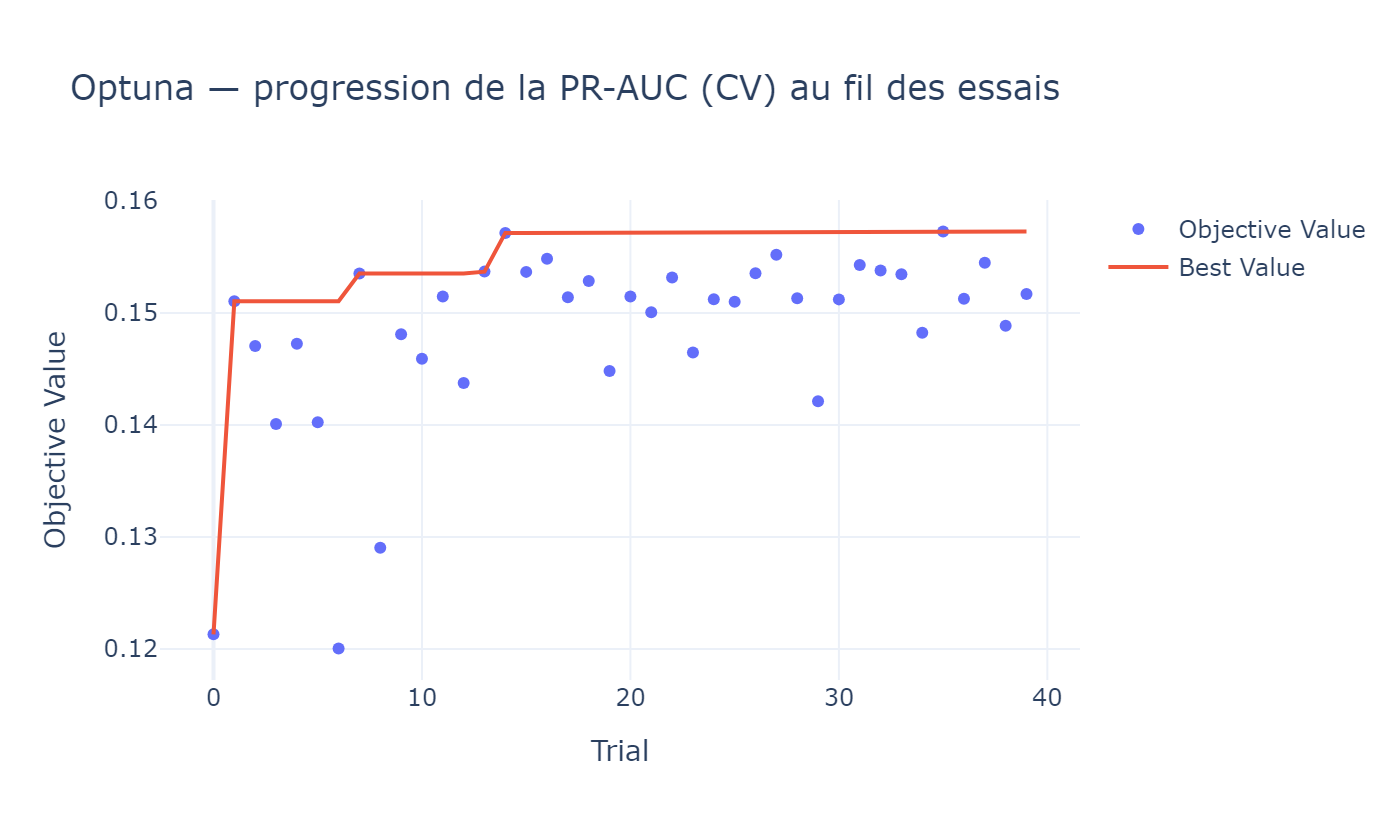

In [4]:
import os, optuna.visualization as vis
from IPython.display import Image
os.makedirs("DEV/images", exist_ok=True)
fig = vis.plot_optimization_history(study)
fig.update_layout(template="plotly_white", height=420,
                  title="Optuna : progression de la PR-AUC (CV) au fil des essais")
fig.write_image("DEV/images/optuna_history.png", scale=2)
Image(filename="DEV/images/optuna_history.png")

## Contrôle de généralisation sur le holdout

On entraîne le meilleur modèle sur `train_dev` (features produit apprises sur dev,
appliquées au HO) et on mesure la PR-AUC sur le **holdout jamais vu**.


In [5]:
best = dict(study.best_params); best["subsample_freq"] = 1

Xd, yd, Xh = prepare(idev, iho); yh = y.iloc[iho].reset_index(drop=True)
Xd, Xh = enc_fit(Xd, yd, Xh)
m_ho = lgb.LGBMClassifier(**best, random_state=SEED, n_jobs=-1, verbosity=-1).fit(Xd, yd)
ap_ho = average_precision_score(yh, m_ho.predict_proba(Xh)[:, 1])
print(f"PR-AUC CV (train_dev) : {study.best_value:.4f}")
print(f"PR-AUC HO (jamais vu) : {ap_ho:.4f}")
ecart = abs(study.best_value - ap_ho)
print(f"écart : {ecart:.4f}  ->  {'généralise bien' if ecart < 0.02 else 'à surveiller'}")

PR-AUC CV (train_dev) : 0.1573
PR-AUC HO (jamais vu) : 0.1675
écart : 0.0102  ->  généralise bien


## Modèle final et soumission

Refit sur **tout le train** (tables produit apprises sur tout le train, appliquées au
test), prédiction, puis soumission versionnée dans `DEV/soumission/` (2 paniers synthétiques
à 0).


In [6]:
import os
B_test = load_baskets("data/X_test_clean.csv")
Ftest  = pd.read_csv("data/features_test.csv"); id_test = Ftest["ID"]

tb, g  = fit_tables(ids.tolist(), y.to_numpy(), B)                       # tables sur TOUT le train
pf_tr  = apply_tables(tb, g, ids.tolist(), B).reset_index(drop=True)
pf_te  = apply_tables(tb, g, id_test.tolist(), B_test).reset_index(drop=True)
Xtr    = pd.concat([Xstat.reset_index(drop=True), pf_tr], axis=1)[FEATURES]
Xte    = pd.concat([Ftest[STATIC].reset_index(drop=True), pf_te], axis=1)[FEATURES]
Xtr, Xte = enc_fit(Xtr, y, Xte)

model = lgb.LGBMClassifier(**best, random_state=SEED, n_jobs=-1, verbosity=-1).fit(Xtr, y)
proba = model.predict_proba(Xte)[:, 1]

allids = pd.read_csv("data/X_test_clean.csv", usecols=["ID", "is_synthetic"])
pred = dict(zip(id_test, proba))
allids["fraud_flag"] = allids["ID"].map(pred).fillna(0.0)
sub = allids[["ID", "fraud_flag"]].reset_index(drop=True)

VERSION = "v2_lgbm_optuna_produit"
os.makedirs("DEV/soumission", exist_ok=True)
path = f"DEV/soumission/submission_{VERSION}_ho{ap_ho:.3f}.csv"
sub.to_csv(path)
print(f"écrit : {path}")
print(f"soumission : {len(sub):,} lignes (dont {int((allids.is_synthetic==1).sum())} synthétiques à 0)")
print(f"proba : min {proba.min():.4f} | médiane {np.median(proba):.4f} | max {proba.max():.4f}")
sub.head()

écrit : soumission/submission_v2_lgbm_optuna_produit_ho0.167.csv
soumission : 23,198 lignes (dont 2 synthétiques à 0)
proba — min 0.0004 | médiane 0.0063 | max 0.9224


,ID,fraud_flag
0,64707,0.000760
1,63919,0.002053
2,15664,0.005690
3,6626,0.081947
4,26766,0.210714


## Interprétation du modèle final (SHAP)

Graphe SHAP du modèle final sur un échantillon du test. On s'attend à voir les
features **produit** (SKU / modèle) en tête, le grain fin qui fait la performance.


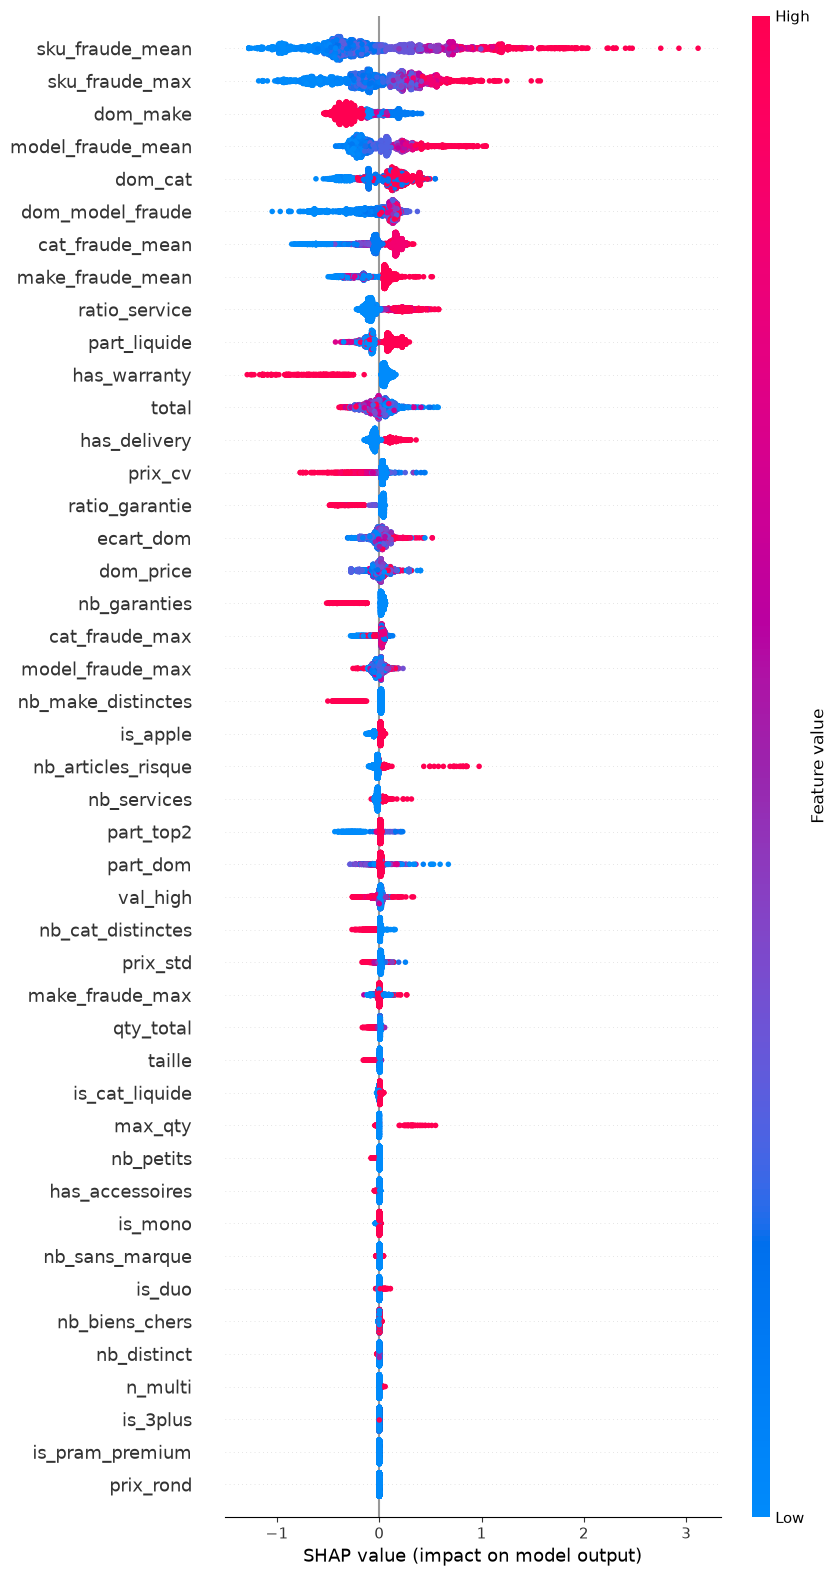

In [7]:
import shap
i4 = np.random.RandomState(0).choice(len(Xte), size=min(4000, len(Xte)), replace=False)
Xte_df = pd.DataFrame(Xte, columns=FEATURES) if not isinstance(Xte, pd.DataFrame) else Xte
expl = shap.TreeExplainer(model)(Xte_df.iloc[i4])
if expl.values.ndim == 3: expl = expl[:, :, 1]
shap.plots.beeswarm(expl, max_display=len(FEATURES))

## Récapitulatif

- **Pool enrichi** : statiques (EDA) + propension-fraude **produit** in-fold.
- **Sans fuite** : tables produit apprises sur le train (du pli / de dev / du train
  complet) et appliquées par lookup ; `dom_cat`/`dom_make` via CatBoostEncoder.
- **Protocole** : holdout isolé → CV + Optuna → contrôle HO → refit complet.
- **Sorties** : soumission versionnée dans `DEV/soumission/`, figures dans `DEV/images/`.

**Résultats mesurés dans ce notebook** : baseline **0,145** en validation croisée,
**0,157** après optimisation Optuna, **0,167** sur le holdout jamais vu. Le protocole
reste sans fuite de bout en bout, et l'écart CV / holdout de 0,010 confirme que le
modèle généralise.